# Credit Card Default Classification in Python

This notebook connects the reusable modules in `src/` to run the full machine-learning workflow:

1. Load and validate the dataset  
2. Clean and recode variables  
3. Create a stratified train/test split  
4. Train L1 Logistic Regression, Bagging, Random Forest, and Gradient Boosting models  
5. Compare Accuracy, Recall, Specificity, Precision, and F1 Score


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Make the project src/ directory importable whether the notebook is
# launched from the repository root or from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from preprocessing import load_data, clean_data, split_data
from modeling import build_models, train_models
from evaluation import compare_models, get_confusion_matrix


## 1. Load the dataset

The project expects the public UCI credit-card dataset to be stored at `data/UCI_Credit_Card.csv`.


In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "UCI_Credit_Card.csv"

raw_data = load_data(DATA_PATH)
print(f"Dataset shape: {raw_data.shape}")
raw_data.head()


Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Inspect the original outcome distribution


In [5]:
target_raw = "default.payment.next.month"
class_counts = raw_data[target_raw].value_counts().sort_index()
class_proportions = raw_data[target_raw].value_counts(normalize=True).sort_index()

pd.DataFrame({
    "Count": class_counts,
    "Proportion": class_proportions.round(4),
})


,Count,Proportion
default.payment.next.month,,
0,23364,0.7788
1,6636,0.2212


## 3. Clean and prepare the data

The reusable preprocessing module removes the identifier, renames the target, and recodes demographic categorical variables.


In [6]:
cleaned_data = clean_data(raw_data)
print(f"Cleaned dataset shape: {cleaned_data.shape}")
cleaned_data.head()


Cleaned dataset shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default
0,20000.0,Female,University,Married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,Female,University,Single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,Female,University,Single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,Female,University,Married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,Male,University,Married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 4. Create a stratified train/test split

A 70/30 split is used. Stratification preserves the proportion of default and non-default cases in both subsets.


In [7]:
X_train, X_test, y_train, y_test = split_data(cleaned_data)

print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)
print("\nTraining outcome proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(4))
print("\nTest outcome proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(4))


Training predictors: (21000, 23)
Test predictors: (9000, 23)

Training outcome proportions:
Default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Test outcome proportions:
Default
0    0.7788
1    0.2212
Name: proportion, dtype: float64


## 5. Build and train the models

Each model is wrapped in a scikit-learn pipeline so preprocessing is applied consistently during fitting and prediction.


In [8]:
models = build_models(X_train)
trained_models = train_models(models, X_train, y_train)

list(trained_models.keys())


/home/codespace/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2071: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/codespace/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2102: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
/home/codespace/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:2129: FutureWarning: The fitted attribute

['L1 Logistic Regression', 'Bagging', 'Random Forest', 'Gradient Boosting']

## 6. Compare model performance

Accuracy is reported, but Recall and F1 are especially important because the default class is less common than the non-default class.


In [9]:
comparison = compare_models(trained_models, X_test, y_test)
comparison


,Model,Accuracy,Recall,Specificity,Precision,F1
0,L1 Logistic Regression,0.8097,0.2275,0.9750,0.7213,0.3459
1,Bagging,0.8176,0.3787,0.9422,0.6506,0.4787
2,Random Forest,0.8172,0.3666,0.9452,0.6553,0.4702
3,Gradient Boosting,0.8240,0.3606,0.9556,0.6978,0.4755


## 7. Visualize the model comparison


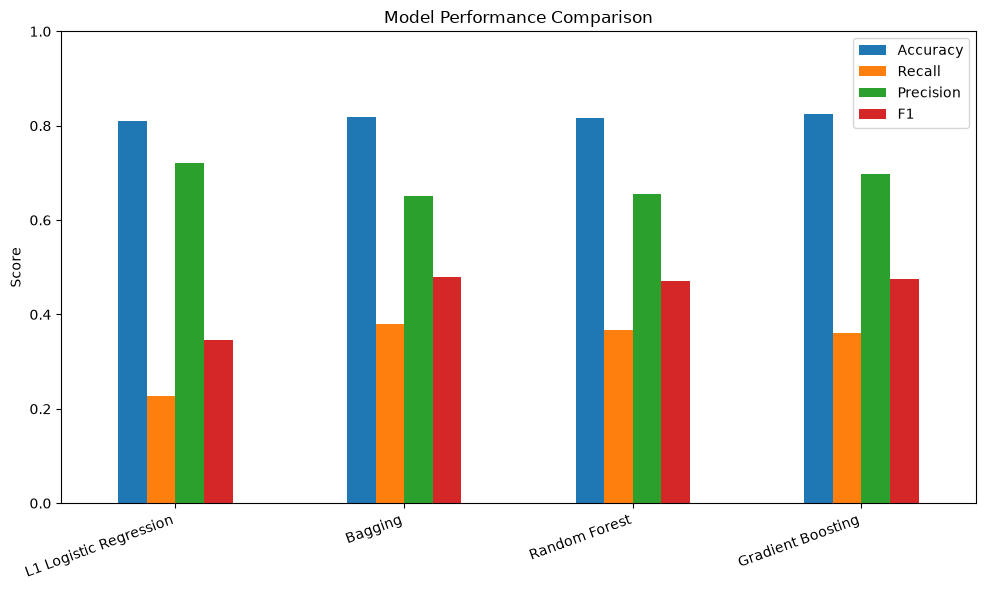

In [10]:
plot_data = comparison.set_index("Model")[["Accuracy", "Recall", "Precision", "F1"]]

ax = plot_data.plot(kind="bar", figsize=(10, 6))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 8. Inspect confusion matrices


In [11]:
for model_name, model in trained_models.items():
    matrix = get_confusion_matrix(model, X_test, y_test)
    matrix_df = pd.DataFrame(
        matrix,
        index=["Actual No Default", "Actual Default"],
        columns=["Predicted No Default", "Predicted Default"],
    )
    print(f"\n{model_name}")
    display(matrix_df)



L1 Logistic Regression


,Predicted No Default,Predicted Default
Actual No Default,6834,175
Actual Default,1538,453



Bagging


,Predicted No Default,Predicted Default
Actual No Default,6604,405
Actual Default,1237,754



Random Forest


,Predicted No Default,Predicted Default
Actual No Default,6625,384
Actual Default,1261,730



Gradient Boosting


,Predicted No Default,Predicted Default
Actual No Default,6698,311
Actual Default,1273,718


## 9. Interpretation

After running the notebook, summarize the practical trade-offs among the models. In particular, compare Recall and F1 rather than selecting a model only by Accuracy.
